# **KNN 모델 검증 (train_test_split 기반)**

### 1. 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import randint

# 한글 폰트 설정
matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rc('axes', unicode_minus=False)

### 2. 데이터 불러오기 및 전처리

In [2]:
# 데이터 불러오기
folder_path = r"C:\Users\chaeh\Desktop\real\project"
df = pd.read_csv(folder_path + r"\new_city.csv", encoding='utf-8-sig')

# 거래금액 전처리 (쉼표 제거 후 정수 변환)
df['거래금액(만원)'] = df['거래금액(만원)'].str.replace(',', '').astype(int)

### 3. 도시명 인코딩

In [3]:
# 도시명을 숫자 코드로 변환
df.loc[df['도시명'] == '운정', '도시명_코드'] = 0
df.loc[df['도시명'] == '송도', '도시명_코드'] = 1
df.loc[df['도시명'] == '청라', '도시명_코드'] = 2
df.loc[df['도시명'] == '판교', '도시명_코드'] = 3
df.loc[df['도시명'] == '광교', '도시명_코드'] = 4

### 4. 이상치 제거

In [4]:
print(f"이상치 제거 전 데이터 건수: {len(df)}")

# 발표후경과년수 3년미만 필터링
before = len(df)
df = df[df['발표후경과년수'] >= 3]
print(f"발표후경과년수 3 미만 제거: {before - len(df)}개 → 남은 데이터: {len(df)}개")

# 전용면적 33제곱미터 미만 제거 (논문 기준: 거래 빈도 낮고 가격 편차 심함)
df = df[df['전용면적(㎡)'] >= 33]
print(f"전용면적 33㎡ 미만 제거 후: {len(df)}")

# 거래금액 z-score 기준 이상치 제거 (|z| > 2인 데이터 제거)
mean = df['거래금액(만원)'].mean()
std = df['거래금액(만원)'].std()
z_scores = (df['거래금액(만원)'] - mean) / std
df = df[z_scores.abs() <= 2]
print(f"z-score 이상치 제거 후: {len(df)}")

이상치 제거 전 데이터 건수: 90761
발표후경과년수 3 미만 제거: 0개 → 남은 데이터: 90761개
전용면적 33㎡ 미만 제거 후: 90759
z-score 이상치 제거 후: 86200


### 5. 독립변수 및 타겟 설정

In [5]:
# 사용할 독립변수 목록
features = ['건축년도', '전용면적(㎡)', '층', '도시명_코드',
            '지하철호선개수', '기차역까지의거리',
            '가장 가까운 지하철역까지의 거리', '가장 가까운 IC와의 거리',
            '발표후경과년수', 'CPI', '계약연도', '서울도심거리', '자족용지비율']

# 결측치 제거
df = df.dropna(subset=features + ['거래금액(만원)'])
print(f"결측치 제거 후 데이터 건수: {len(df)}")

# 독립변수와 타겟 분리
X = df[features]
y = df['거래금액(만원)']

결측치 제거 후 데이터 건수: 86200


### 6. 훈련/테스트 분할 및 표준화

In [6]:
# 훈련 세트와 테스트 세트 분할 (8:2)
train_input, test_input, train_target, test_target = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"훈련 세트 크기: {train_input.shape}")
print(f"테스트 세트 크기: {test_input.shape}")

# 표준화
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

훈련 세트 크기: (68960, 13)
테스트 세트 크기: (17240, 13)


### 7. 기본 KNN 모델 학습 및 성능 평가

In [7]:
# 기본 KNN 모델 학습 (k=5 기본값)
knn = KNeighborsRegressor()
knn.fit(train_scaled, train_target)

# R2 점수 확인
print(f"훈련 세트 R²: {knn.score(train_scaled, train_target):.4f}")
print(f"테스트 세트 R²: {knn.score(test_scaled, test_target):.4f}")

훈련 세트 R²: 0.9548
테스트 세트 R²: 0.9320


### 8. RandomizedSearchCV로 최적 k 탐색

In [8]:
# GridSearchCV(1~10)보다 넓은 범위(1~50)를 탐색
# n_iter=30: 30번 무작위 샘플링으로 탐색
param_dist = {"n_neighbors": randint(1, 51)}  # 1~50 범위에서 무작위 탐색

knn_random = RandomizedSearchCV(
    KNeighborsRegressor(),
    param_dist,
    n_iter=30,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42
)
knn_random.fit(train_scaled, train_target)

best_k = knn_random.best_params_["n_neighbors"]
print(f"최적 k: {best_k}")
print(f"최적 교차검증 RMSE: {math.sqrt(-knn_random.best_score_):,.0f} 만원")

최적 k: 3
최적 교차검증 RMSE: 5,930 만원


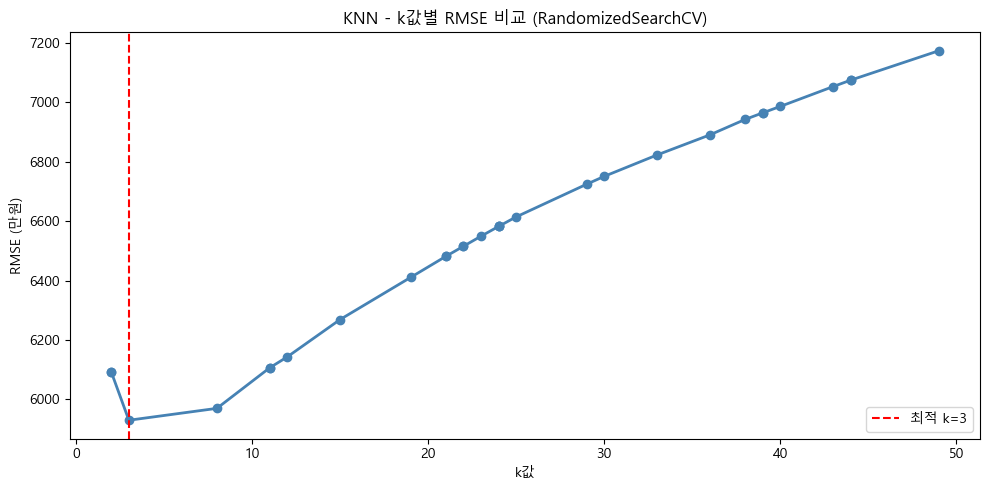

In [9]:
# 탐색된 k값별 RMSE 그래프
cv_results = knn_random.cv_results_
k_list    = [p["n_neighbors"] for p in cv_results["params"]]
rmse_list = [math.sqrt(-s) for s in cv_results["mean_test_score"]]

# k값 기준으로 정렬
sorted_pairs = sorted(zip(k_list, rmse_list))
k_sorted, rmse_sorted = zip(*sorted_pairs)

plt.figure(figsize=(10, 5))
plt.plot(k_sorted, rmse_sorted, marker="o", color="steelblue", linewidth=2)
plt.axvline(x=best_k, color="red", linestyle="--", label=f"최적 k={best_k}")
plt.xlabel("k값")
plt.ylabel("RMSE (만원)")
plt.title("KNN - k값별 RMSE 비교 (RandomizedSearchCV)")
plt.legend()
plt.tight_layout()
plt.show()

### 9. 최적 k로 최종 모델 평가

In [10]:
knn_best = knn_random.best_estimator_
knn_pred = knn_best.predict(test_scaled)

knn_rmse = math.sqrt(mean_squared_error(test_target, knn_pred))
knn_mae  = mean_absolute_error(test_target, knn_pred)
knn_r2   = knn_best.score(test_scaled, test_target)

print(f"[KNN 최종 결과] k={best_k}")
print(f"훈련 세트 R²: {knn_best.score(train_scaled, train_target):.4f}")
print(f"테스트 세트 R²: {knn_r2:.4f}")
print(f"  RMSE : {knn_rmse:,.0f} 만원")
print(f"  MAE  : {knn_mae:,.0f} 만원")

[KNN 최종 결과] k=3
훈련 세트 R²: 0.9653
테스트 세트 R²: 0.9300
  RMSE : 5,663 만원
  MAE  : 3,454 만원


### 10. 실제값 vs 예측값 산점도

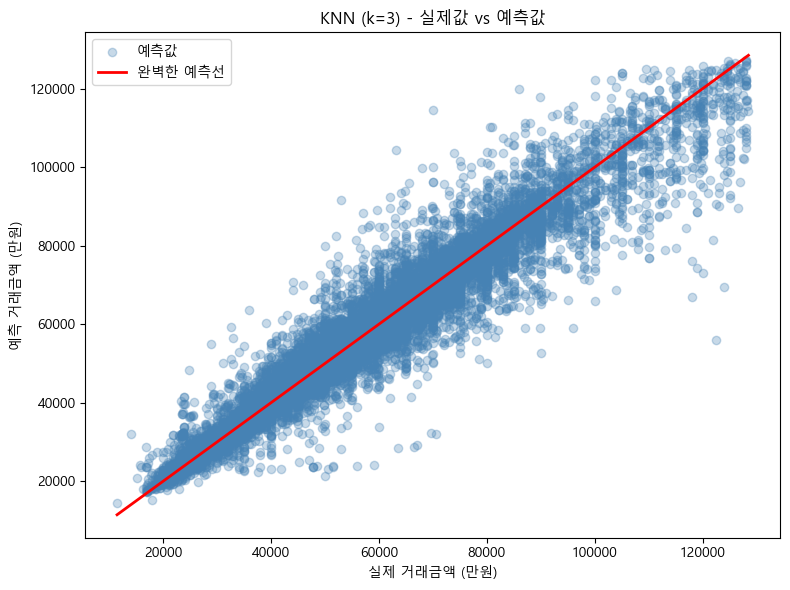

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(test_target, knn_pred, alpha=0.3, color="steelblue", label="예측값")
plt.plot([test_target.min(), test_target.max()],
         [test_target.min(), test_target.max()],
         color="red", linewidth=2, label="완벽한 예측선")
plt.xlabel("실제 거래금액 (만원)")
plt.ylabel("예측 거래금액 (만원)")
plt.title(f"KNN (k={best_k}) - 실제값 vs 예측값")
plt.legend()
plt.tight_layout()
plt.show()

### 11. 잔차 분포

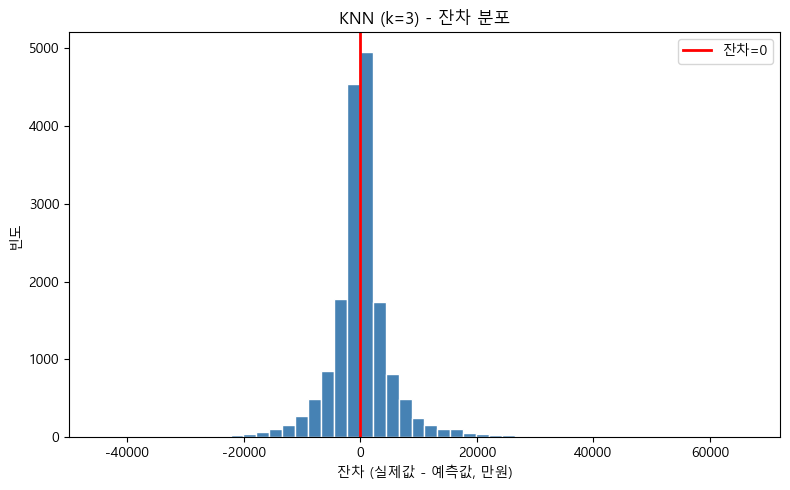

In [12]:
residuals = test_target.values - knn_pred

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50, color="steelblue", edgecolor="white")
plt.axvline(x=0, color="red", linewidth=2, label="잔차=0")
plt.xlabel("잔차 (실제값 - 예측값, 만원)")
plt.ylabel("빈도")
plt.title(f"KNN (k={best_k}) - 잔차 분포")
plt.legend()
plt.tight_layout()
plt.show()